## 3D Spatial Interpolation in Neural Processes

In [1]:
import neuralprocesses as nps
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

#### Generate a dense vector field for testing

This should be a field of 2d vectors in a 3d grid.

In [2]:
b_size = 16
x_size = 20
y_size = 20
z_size = 6

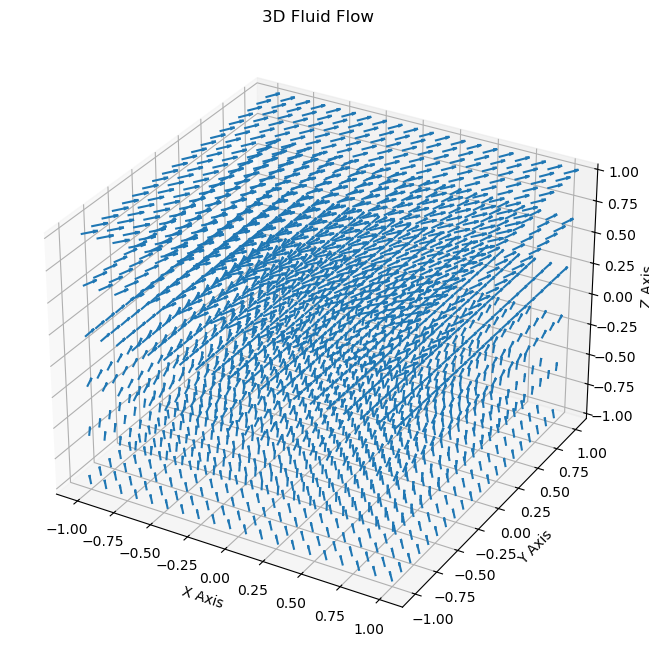

In [3]:
def random_velocity_field(batch, dim_x, dim_y, dim_z):
    velocity_field_batch = np.zeros((batch, dim_x, dim_y, dim_z, 2))  # shape: (batch, dim_x, dim_y, dim_z, 2)
    
    for b in range(batch):
        # scale increases with z to create larger vectors at higher z levels
        scale = 1 + (b / batch) * 2  # scale from 1 to 3 across the batch

        # offset the center of the flow significantly to create more uniform patterns
        offset_x = random.uniform(-0.5, 0.5) * 100
        offset_y = random.uniform(-0.5, 0.5) * 100
        
        x, y, z = np.meshgrid(np.linspace(-1, 1, dim_x),
                        np.linspace(-1, 1, dim_y),
                        np.linspace(-1, 1, dim_z))

        # apply a function to create a more complex flow pattern
        u = scale * (random.randrange(0, 2)/10 * np.sin(1/100 * offset_x + random.random() * z) + np.sin(1/100 * random.random() * x) * np.cos(1/100 * random.random() * y))
        v = scale * (random.randrange(0, 2)/10 * np.cos(1/100 * offset_y + random.random() * z) + 0.5 * np.cos(1/100 * np.pi * random.random() * x) * np.sin(1/100 * np.pi * random.random() * y))
        w = np.zeros_like(z) # no vertical flow

        velocity_field = np.stack((u, v), axis=-1)  # shape: (dim_x, dim_y, dim_z, 3)
        velocity_field_batch[b, :, :, :] = velocity_field

    return velocity_field_batch

velocity_field_batch = random_velocity_field(b_size, x_size, y_size, z_size)

x, y, z = np.meshgrid(np.linspace(-1, 1, x_size), np.linspace(-1, 1, y_size), np.linspace(-1, 1, z_size))
u = velocity_field_batch[0, :, :, :, 0]  # shape: (x_size, y_size, z_size)
v = velocity_field_batch[0, :, :, :, 1]  # shape: (x_size, y_size, z_size)
w = np.zeros_like(u)  # shape: (x_size, y_size)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(x, y, z, u, v, w, length=0.1, normalize=True)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Fluid Flow')
plt.show()

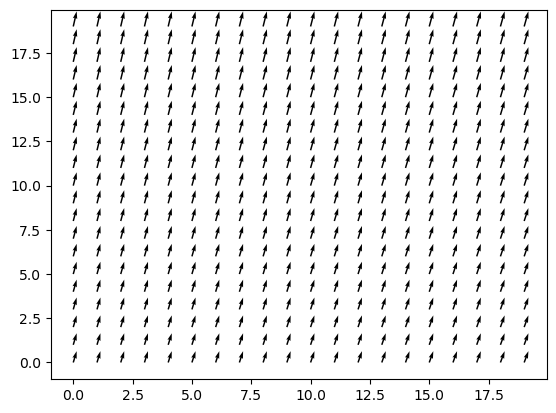

In [4]:
level = 4

plt.quiver(velocity_field_batch[0, :, :, level, 0], velocity_field_batch[0, :, :, level, 1])

#### pass through neuralprocesses

In [5]:
import lab.torch as B
import neuralprocesses.torch as nps

In [6]:
torch.set_default_device("cuda")
B.set_global_device("cuda")

In [7]:
cnp = nps.construct_convgnp(
    dim_x=3,
    dim_yc=(2,),
    dim_yt=2,
    likelihood="lowrank", 
    conv_arch="unet-res-sep", 
    unet_channels=(4, 4), 
    unet_kernels=5,
    points_per_unit=5)

x, y, z = torch.meshgrid(
    torch.linspace(-1, 1, x_size),
    torch.linspace(-1, 1, y_size),
    torch.linspace(-1, 1, z_size),
    indexing='ij'
)

xc_grid = torch.stack((x, y, z), dim=0)  
xc_grid = xc_grid.unsqueeze(0).repeat(b_size, 1, 1, 1, 1)
xt = xc_grid

yc_grid = torch.tensor(velocity_field_batch, dtype=torch.float32)  # shape: (x_size, y_size, z_size, 2)
yc_grid = yc_grid.permute(0, 4, 1, 2, 3)

# mask some inputs
mask = torch.ones(b_size, x_size, y_size, z_size, dtype=torch.float32)

# mask out 50% of the points randomly
mask = mask.flatten(1)  # shape: (b_size, x_size * y_size * z_size)
for i in range(mask.shape[0]):
    indices = torch.randperm(mask.shape[1])[:mask.shape[1] // 2]
    mask[i, indices] = 0
    
mask = mask.view(b_size, x_size, y_size, z_size)  # shape: (b_size, x_size, y_size, z_size)
mask = mask.unsqueeze(1) # shape: (b_size, 1, x_size, y_size, z_size) to match yc_grid's shape

In [8]:
xc = xc_grid.reshape(b_size, 3, -1)
yc = yc_grid.reshape(b_size, 2, -1)
xt = xt.reshape(b_size, 3, -1)
mask_flat = mask.reshape(b_size, 1, -1)

# test that prediction works
pred = cnp(
    [(xc, nps.Masked(yc, mask_flat))],
    xt
)

/home/lennoxc/jetstream/jetstream-interpolate-convcnp/.pixi/envs/default/lib/python3.14/site-packages/lab/types.py:205: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numerictypes.
  for name in np.core.numerictypes.__all__ + ["bool"]:


### Training

In [9]:
opt = torch.optim.Adam(cnp.parameters(), 1e-3)
steps = 100
mask_denominator = 2

In [10]:
losses = []

for i in range(100):
    if i+1 % 10 == 0:
        print(f"Step {i+1}/{steps}")
    velocity_field_batch = random_velocity_field(b_size, x_size, y_size, z_size)

    yc_grid = torch.tensor(velocity_field_batch, dtype=torch.float32)  # shape: (x_size, y_size, z_size, 2)
    yc_grid = yc_grid.permute(0, 4, 1, 2, 3)

    # mask some inputs
    mask = torch.ones(b_size, x_size, y_size, z_size, dtype=torch.float32)

    # mask out points randomly
    mask = mask.flatten(1)  # shape: (b_size, x_size * y_size * z_size)
    for i in range(mask.shape[0]):
        indices = torch.randperm(mask.shape[1])[:mask.shape[1] // mask_denominator]
        mask[i, indices] = 0
        
    mask = mask.view(b_size, x_size, y_size, z_size)  # shape: (b_size, x_size, y_size, z_size)
    mask = mask.unsqueeze(1) # shape: (b_size, 1, x_size, y_size, z_size) to match yc_grid's shape

    opt.zero_grad()

    loss = torch.mean(nps.loglik(
        cnp, 
        [(xc, nps.Masked(yc, mask_flat))],
        xt,
        yc,
        normalize=True)
    )
    
    loss.backward()
    opt.step()

    losses.append(loss.item())

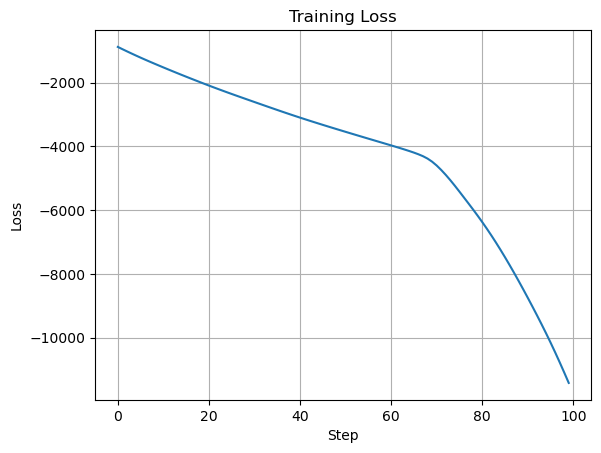

In [11]:
plt.plot(losses)
plt.grid()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

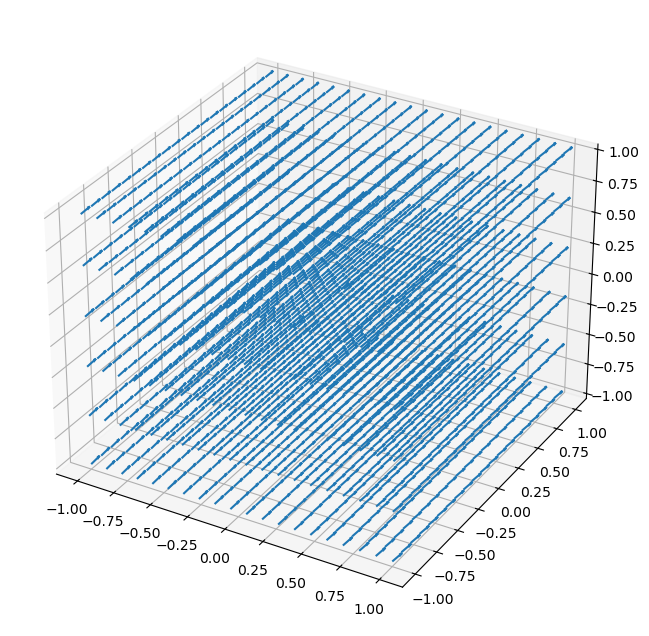

In [39]:
# create a new velocity field for testing
test_velocity_field = random_velocity_field(16, x_size, y_size, z_size)

ith_test_velocity_field = test_velocity_field[0, :, :, :, :]

# plot the test velocity field
x, y, z = np.meshgrid(np.linspace(-1, 1, x_size), np.linspace(-1, 1, y_size), np.linspace(-1, 1, z_size))
u = ith_test_velocity_field[0, :, :, 0]  # shape: (x_size, y_size, z_size)
v = ith_test_velocity_field[0, :, :, 1]  # shape: (x_size, y_size, z_size)
w = np.zeros_like(u)  # shape: (x_size, y_size)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(x, y, z, u, v, w, length=0.1, normalize=True)

In [40]:
# mask out some inputs
mask = torch.ones(b_size, x_size, y_size, z_size, dtype=torch.float32)
# mask out points randomly
mask = mask.flatten(1)  # shape: (b_size, x_size * y_size * z_size)
for i in range(mask.shape[0]):
    indices = torch.randperm(mask.shape[1])[:mask.shape[1] // mask_denominator]
    mask[i, indices] = 0
    
mask = mask.view(b_size, x_size, y_size, z_size)  # shape: (b_size, x_size, y_size, z_size)
mask = mask.unsqueeze(1) # shape: (b_size, 1, x_size, y_size, z_size) to match yc_grid's shape

In [41]:
yc_test = torch.tensor(test_velocity_field, dtype=torch.float32)  # shape: (x_size, y_size, z_size, 2)
yc_test = yc_grid.permute(0, 4, 1, 2, 3)
yc_test = yc_test.reshape(b_size, 2, -1)

In [42]:
pred = cnp(
    [(xc, nps.Masked(yc_test, mask_flat))],
    xt
)

In [43]:
pred = pred.mean

In [44]:
pred = pred.to("cpu").detach().numpy()

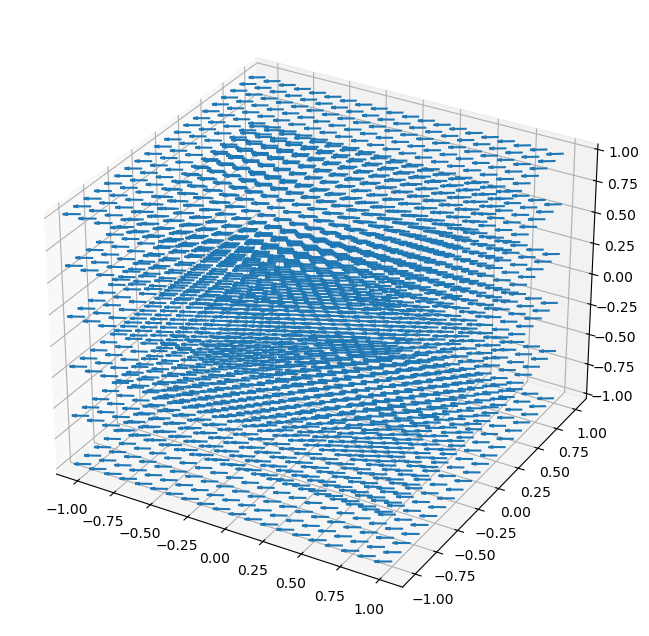

In [45]:
# pred shape is [2, 2400]. Reshape it back to (x_size, y_size, z_size, 2) for visualization
pred = pred.reshape(b_size, 2, x_size, y_size, z_size)
pred = pred[0].transpose(1, 2, 3, 0) # shape: (x_size, y_size, z_size, 2)

# plot the predicted velocity field
u_pred = pred[:, :, :, 0] # shape: (x_size, y_size, z_size)
v_pred = pred[:, :, :, 1] # shape: (x_size, y_size, z_size)
w_pred = np.zeros_like(u_pred)  # shape: (x_size, y_size)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(x, y, z, u_pred, v_pred, w_pred, length=0.1, normalize=True)